# Phase 3B.2 - Final Additive Stimulus-Based Bayesian Model

This notebook fits the supervisor-aligned stimulus-based Bayesian multilevel model to the final 5-mix / 3-context synthetic dataset created in Phase 3B.1. The data are synthetic and are used only for pipeline validation, model debugging, posterior uncertainty checks, ICC recovery, and preparation for later empirical analysis.

## 1. Imports, Runtime Configuration, and Reproducibility

Bambi/PyMC is used for Gaussian Bayesian multilevel regression. Sampling uses a deterministic seed and the CPU-compatible `nutpie` NUTS backend.

In [1]:
from __future__ import annotations

import importlib.metadata as metadata
import json
import os
import sys
import time
from pathlib import Path

CACHE_ROOT = Path(os.environ.get("TEMP", ".")) / "phase3b2_cache"
(CACHE_ROOT / "pytensor").mkdir(parents=True, exist_ok=True)
(CACHE_ROOT / "numba").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("PYTENSOR_FLAGS", f"cxx=,base_compiledir={(CACHE_ROOT / 'pytensor').as_posix()}")
os.environ.setdefault("NUMBA_CACHE_DIR", str(CACHE_ROOT / "numba"))

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import display

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
az.rcParams["plot.max_subplots"] = 40

SAMPLING_CONFIG = {
    "draws": 1000,
    "tune": 1000,
    "chains": 4,
    "cores": 1,
    "target_accept": 0.95,
    "random_seed": SEED,
    "inference_method": "nutpie",
}

def package_version(package_name: str) -> str:
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return "not installed"

version_report = pd.DataFrame([
    {"component": "Python", "version": sys.version.split()[0]},
    {"component": "Bambi", "version": bmb.__version__},
    {"component": "PyMC", "version": pm.__version__},
    {"component": "ArviZ", "version": az.__version__},
    {"component": "NumPy", "version": np.__version__},
    {"component": "pandas", "version": pd.__version__},
    {"component": "matplotlib", "version": metadata.version("matplotlib")},
    {"component": "nutpie", "version": package_version("nutpie")},
])
display(version_report)
display(pd.DataFrame([SAMPLING_CONFIG]))

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


,component,version
0,Python,3.13.9
1,Bambi,0.17.2
2,PyMC,5.28.5
3,ArviZ,0.23.4
4,NumPy,2.3.5
5,pandas,2.3.3
6,matplotlib,3.10.6
7,nutpie,0.16.11


,draws,tune,chains,cores,target_accept,random_seed,inference_method
0,1000,1000,4,1,0.95,42,nutpie


## 2. Paths and Data Loading

The notebook loads only the Phase 3B.1 final synthetic exports and writes new model outputs to `statistical-baseline/outputs/stimulus_model`.

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    markers = [
        Path("statistical-baseline/data/synthetic/final_5mix_synthetic_ratings_seed42.csv"),
        Path("study-interface/frontend-5mix/config/stimuli.json"),
    ]
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate repository root.")

REPO_ROOT = find_repo_root()
SYNTHETIC_DIR = REPO_ROOT / "statistical-baseline" / "data" / "synthetic"
OUTPUT_DIR = REPO_ROOT / "statistical-baseline" / "outputs" / "stimulus_model"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RATINGS_PATH = SYNTHETIC_DIR / "final_5mix_synthetic_ratings_seed42.csv"
STIMULUS_METADATA_PATH = SYNTHETIC_DIR / "final_5mix_stimulus_metadata_seed42.csv"
TRUE_ICC_PATH = SYNTHETIC_DIR / "final_5mix_true_variance_icc_seed42.csv"
TRIAL_PREFERENCES_PATH = SYNTHETIC_DIR / "final_5mix_trial_preferences_seed42.csv"
GENERATING_PARAMETERS_PATH = SYNTHETIC_DIR / "final_5mix_generating_parameters_seed42.json"

ratings = pd.read_csv(RATINGS_PATH)
stimulus_metadata = pd.read_csv(STIMULUS_METADATA_PATH)
trial_preferences = pd.read_csv(TRIAL_PREFERENCES_PATH)
true_variance_icc = pd.read_csv(TRUE_ICC_PATH)
with GENERATING_PARAMETERS_PATH.open("r", encoding="utf-8") as handle:
    generating_parameters = json.load(handle)

pd.DataFrame([
    {"label": "ratings", "path": RATINGS_PATH.relative_to(REPO_ROOT)},
    {"label": "stimulus_metadata", "path": STIMULUS_METADATA_PATH.relative_to(REPO_ROOT)},
    {"label": "true_icc", "path": TRUE_ICC_PATH.relative_to(REPO_ROOT)},
    {"label": "trial_preferences", "path": TRIAL_PREFERENCES_PATH.relative_to(REPO_ROOT)},
    {"label": "output_dir", "path": OUTPUT_DIR.relative_to(REPO_ROOT)},
])

,label,path
0,ratings,statistical-baseline\data\synthetic\final_5mix...
1,stimulus_metadata,statistical-baseline\data\synthetic\final_5mix...
2,true_icc,statistical-baseline\data\synthetic\final_5mix...
3,trial_preferences,statistical-baseline\data\synthetic\final_5mix...
4,output_dir,statistical-baseline\outputs\stimulus_model


## 3. Validate and Prepare Modelling Variables

Reference levels are explicit: `EDR-1` for episode and `group_01` for group.

In [3]:
REQUIRED_COLUMNS = ["participant_id", "group", "song_id", "mix_id", "stimulus_id", "episode", "rating"]
missing = sorted(set(REQUIRED_COLUMNS) - set(ratings.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

EPISODE_LEVELS = ["EDR-1", "EDR-2", "FM-1"]
GROUP_LEVELS = ["group_01", "group_02"]
PARTICIPANT_LEVELS = sorted(ratings["participant_id"].unique())
STIMULUS_LEVELS = stimulus_metadata["stimulus_id"].tolist()

model_df = ratings.copy()
model_df["episode"] = pd.Categorical(model_df["episode"], categories=EPISODE_LEVELS)
model_df["group"] = pd.Categorical(model_df["group"], categories=GROUP_LEVELS)
model_df["participant_id"] = pd.Categorical(model_df["participant_id"], categories=PARTICIPANT_LEVELS)
model_df["stimulus_id"] = pd.Categorical(model_df["stimulus_id"], categories=STIMULUS_LEVELS)

validation_checks = []
def add_check(check, observed, expected, passed=None):
    if passed is None:
        passed = observed == expected
    validation_checks.append({"check": check, "observed": observed, "expected": expected, "passed": bool(passed)})

ratings_per_participant = model_df.groupby("participant_id", observed=True).size()
obs_per_stimulus = model_df.groupby("stimulus_id", observed=True).size()
add_check("Rows", len(model_df), 1200)
add_check("Participants", model_df["participant_id"].nunique(), 40)
add_check("Stimuli", model_df["stimulus_id"].nunique(), 20)
add_check("Songs", model_df["song_id"].nunique(), 4)
add_check("Groups", model_df["group"].nunique(), 2)
add_check("Episodes", model_df["episode"].nunique(), 3)
add_check("Ratings per participant", ratings_per_participant.unique().tolist(), [30], (ratings_per_participant == 30).all())
add_check("Complete modelling variables", "complete", "complete", model_df[REQUIRED_COLUMNS].notna().all().all())
add_check("Ratings within 0-100", [float(model_df["rating"].min()), float(model_df["rating"].max())], [0, 100], model_df["rating"].between(0, 100).all())
add_check("Five candidate stimuli per song", stimulus_metadata.groupby("song_id")["stimulus_id"].nunique().to_dict(), "all songs have 5", (stimulus_metadata.groupby("song_id")["stimulus_id"].nunique() == 5).all())
validation_summary = pd.DataFrame(validation_checks)
display(validation_summary)
if not validation_summary["passed"].all():
    raise AssertionError("Input validation failed.")
display(pd.DataFrame([
    {"factor": "episode", "reference_level": EPISODE_LEVELS[0], "levels": " | ".join(EPISODE_LEVELS)},
    {"factor": "group", "reference_level": GROUP_LEVELS[0], "levels": " | ".join(GROUP_LEVELS)},
]))

,check,observed,expected,passed
0,Rows,1200,1200,True
1,Participants,40,40,True
2,Stimuli,20,20,True
3,Songs,4,4,True
4,Groups,2,2,True
5,Episodes,3,3,True
6,Ratings per participant,[30],[30],True
7,Complete modelling variables,complete,complete,True
8,Ratings within 0-100,"[27.8148157630603, 100.0]","[0, 100]",True
9,Five candidate stimuli per song,"{'id_like_to_know': 5, 'in_the_meantime': 5, '...",all songs have 5,True


,factor,reference_level,levels
0,episode,EDR-1,EDR-1 | EDR-2 | FM-1
1,group,group_01,group_01 | group_02


## 4. Descriptive Structure Before Fitting

These summaries check the synthetic outcome and repeated-measures structure. They are not empirical participant findings.

In [4]:
descriptive_summary = pd.DataFrame([
    {"metric": "mean_rating", "value": model_df["rating"].mean()},
    {"metric": "sd_rating", "value": model_df["rating"].std(ddof=1)},
    {"metric": "min_rating", "value": model_df["rating"].min()},
    {"metric": "max_rating", "value": model_df["rating"].max()},
])
participant_count_by_group = model_df[["participant_id", "group"]].drop_duplicates().groupby("group", observed=True).size().rename("n_participants").reset_index()
mean_by_episode = model_df.groupby("episode", observed=True)["rating"].agg(["mean", "std", "count"]).reset_index()
mean_by_group = model_df.groupby("group", observed=True)["rating"].agg(["mean", "std", "count"]).reset_index()
mean_by_stimulus = model_df.groupby(["song_id", "stimulus_id"], observed=True)["rating"].agg(["mean", "std", "count"]).reset_index()
for title, table in [
    ("Descriptive summary", descriptive_summary),
    ("Participant count by group", participant_count_by_group),
    ("Observations per participant", ratings_per_participant.describe().rename("observations_per_participant").reset_index()),
    ("Observations per stimulus", obs_per_stimulus.describe().rename("observations_per_stimulus").reset_index()),
    ("Mean rating by episode", mean_by_episode),
    ("Mean rating by group", mean_by_group),
    ("Mean rating by stimulus", mean_by_stimulus),
]:
    print(f"\n{title}")
    display(table)


Descriptive summary


,metric,value
0,mean_rating,67.635500
1,sd_rating,12.483645
2,min_rating,27.814816
3,max_rating,100.000000



Participant count by group


,group,n_participants
0,group_01,20
1,group_02,20



Observations per participant


...

,episode,mean,std,count
0,EDR-1,68.740531,12.323781,400
1,EDR-2,65.759160,12.710902,400
2,FM-1,68.406810,12.227538,400



Mean rating by group


,group,mean,std,count
0,group_01,69.514215,12.371946,600
1,group_02,65.756786,12.320998,600



Mean rating by stimulus


,song_id,stimulus_id,mean,std,count
0,id_like_to_know,id_like_to_know_pxl_s3,68.027102,12.291945,60
1,id_like_to_know,id_like_to_know_pxl_s5,69.475152,10.928340,60
2,id_like_to_know,id_like_to_know_pxl_s1,69.645410,12.416093,60
3,id_like_to_know,id_like_to_know_pxl_s2,72.106993,12.477438,60
4,id_like_to_know,id_like_to_know_pxl_s7,70.310083,13.577061,60
5,in_the_meantime,in_the_meantime_qut_b,66.493565,10.705118,60
6,in_the_meantime,in_the_meantime_du_h,70.271703,11.639265,60
7,in_the_meantime,in_the_meantime_du_i,57.960539,13.816679,60
8,in_the_meantime,in_the_meantime_du_k,65.502316,10.109763,60
9,in_the_meantime,in_the_meantime_qut_pro,65.592858,11.368469,60


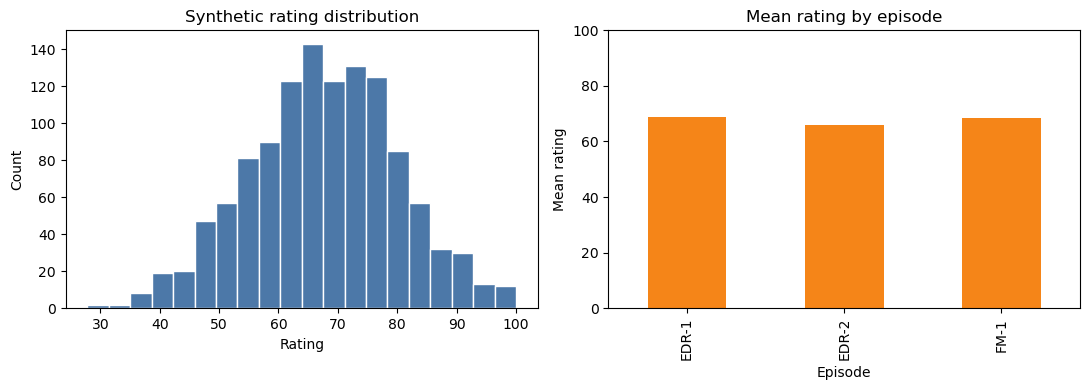

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(model_df["rating"], bins=20, color="#4C78A8", edgecolor="white")
axes[0].set_title("Synthetic rating distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
mean_by_episode.plot(kind="bar", x="episode", y="mean", ax=axes[1], color="#F58518", legend=False)
axes[1].set_title("Mean rating by episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Mean rating")
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 5. Priors and Model Specifications

The debug model is `rating ~ 1 + (1 | participant_id) + (1 | stimulus_id)`. The final primary model is `rating ~ episode + group + (1 | participant_id) + (1 | stimulus_id)`. Bambi's default weakly regularising Gaussian priors are used and automatically scaled in rating-point units.

In [6]:
INTERCEPT_ONLY_FORMULA = "rating ~ 1 + (1 | participant_id) + (1 | stimulus_id)"
FULL_MODEL_FORMULA = "rating ~ episode + group + (1 | participant_id) + (1 | stimulus_id)"
intercept_model = bmb.Model(INTERCEPT_ONLY_FORMULA, model_df, family="gaussian")
full_model = bmb.Model(FULL_MODEL_FORMULA, model_df, family="gaussian")
print("Intercept-only model priors:")
intercept_model.build()
print(intercept_model)
print("\nFinal additive stimulus model priors:")
full_model.build()
print(full_model)

Intercept-only model priors:
       Formula: rating ~ 1 + (1 | participant_id) + (1 | stimulus_id)
        Family: gaussian
          Link: mu = identity
  Observations: 1200
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 67.6355, sigma: 31.1961)
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 31.1961))
            1|stimulus_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 31.1961))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 12.4784)

Final additive stimulus model priors:
       Formula: rating ~ episode + group + (1 | participant_id) + (1 | stimulus_id)
        Family: gaussian
          Link: mu = identity
  Observations: 1200
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 67.6355, sigma: 54.0332)
            episode ~ Normal(mu: [0. 0.], sigma: [66.1769 66.1769])
            group ~ 

## 6. Helper Functions

ICC calculations are performed draw-by-draw from posterior variance components, not from posterior mean SDs.

In [7]:
def stack_sample(da):
    return da.stack(sample=("chain", "draw")).transpose("sample", ...)

def get_single_extra_dim(da):
    extra = [dim for dim in da.dims if dim not in {"chain", "draw"}]
    if len(extra) != 1:
        raise ValueError(f"Expected one non-sample dimension for {da.name}; found {extra}")
    return extra[0]

def draw_values(idata, var_name, level=None):
    da = idata.posterior[var_name]
    if level is not None:
        dim = get_single_extra_dim(da)
        da = da.sel({dim: level})
    return stack_sample(da).values

def coefficient_draws(idata, var_name, level, n_samples):
    if var_name not in idata.posterior:
        return np.zeros(n_samples)
    if level is None:
        return draw_values(idata, var_name)
    da = idata.posterior[var_name]
    dim = get_single_extra_dim(da)
    if level not in set(map(str, da.coords[dim].values)):
        return np.zeros(n_samples)
    return draw_values(idata, var_name, level)

def hdi_bounds(values, hdi_prob=0.94):
    hdi = az.hdi(np.asarray(values), hdi_prob=hdi_prob)
    return float(hdi[0]), float(hdi[1])

def summarise_draw_array(values, label):
    values = np.asarray(values).reshape(-1)
    lower, upper = hdi_bounds(values)
    return {"parameter": label, "mean": float(np.mean(values)), "median": float(np.median(values)), "sd": float(np.std(values, ddof=1)), "hdi_3%": lower, "hdi_97%": upper}

def add_median_to_summary(idata, var_names, summary):
    medians = []
    for var_name in var_names:
        da = idata.posterior[var_name]
        extra_dims = [dim for dim in da.dims if dim not in {"chain", "draw"}]
        if not extra_dims:
            medians.append({"parameter": var_name, "median": float(np.median(stack_sample(da).values))})
            continue
        if len(extra_dims) != 1:
            continue
        dim = extra_dims[0]
        for coord in da.coords[dim].values:
            medians.append({"parameter": f"{var_name}[{coord}]", "median": float(np.median(draw_values(idata, var_name, str(coord))))})
    return summary.merge(pd.DataFrame(medians), on="parameter", how="left")

def arviz_parameter_summary(idata, var_names):
    summary = az.summary(idata, var_names=var_names, hdi_prob=0.94, kind="all").reset_index(names="parameter")
    keep = ["parameter", "mean", "sd", "hdi_3%", "hdi_97%", "mcse_mean", "ess_bulk", "ess_tail", "r_hat"]
    summary = summary[[col for col in keep if col in summary.columns]]
    summary = add_median_to_summary(idata, var_names, summary)
    ordered = ["parameter", "mean", "median", "sd", "hdi_3%", "hdi_97%", "mcse_mean", "ess_bulk", "ess_tail", "r_hat"]
    return summary[[col for col in ordered if col in summary.columns]]

def compute_icc_draws(idata):
    participant_sd = draw_values(idata, "1|participant_id_sigma")
    stimulus_sd = draw_values(idata, "1|stimulus_id_sigma")
    residual_sd = draw_values(idata, "sigma")
    participant_variance = participant_sd ** 2
    stimulus_variance = stimulus_sd ** 2
    residual_variance = residual_sd ** 2
    total = participant_variance + stimulus_variance + residual_variance
    return pd.DataFrame({
        "participant_sd": participant_sd,
        "stimulus_sd": stimulus_sd,
        "residual_sd": residual_sd,
        "participant_variance": participant_variance,
        "stimulus_variance": stimulus_variance,
        "residual_variance": residual_variance,
        "participant_ICC": participant_variance / total,
        "stimulus_ICC": stimulus_variance / total,
        "residual_share": residual_variance / total,
    })

def summarise_derived_draws(draw_df, columns):
    return pd.DataFrame([summarise_draw_array(draw_df[column].to_numpy(), column) for column in columns])

def convergence_diagnostics(idata, model_label):
    summary = az.summary(idata, hdi_prob=0.94, kind="diagnostics")
    sample_stats = idata.sample_stats
    divergences = int(sample_stats["diverging"].sum().item()) if "diverging" in sample_stats else np.nan
    maxdepth = int(sample_stats["maxdepth_reached"].sum().item()) if "maxdepth_reached" in sample_stats else 0
    bfmi = az.bfmi(idata)
    return {"model": model_label, "divergences": divergences, "max_rhat": float(summary["r_hat"].max()), "min_bulk_ess": float(summary["ess_bulk"].min()), "min_tail_ess": float(summary["ess_tail"].min()), "max_treedepth_warnings": maxdepth, "min_bfmi": float(np.min(bfmi))}

def sanitise_idata_attrs_for_netcdf(idata):
    valid_scalar = (str, bytes, int, float, np.integer, np.floating)
    for key, value in list(idata.attrs.items()):
        if not isinstance(value, valid_scalar + (list, tuple, np.ndarray)):
            idata.attrs[key] = json.dumps(value, default=str)
    for group_name in idata.groups():
        dataset = getattr(idata, group_name)
        for key, value in list(dataset.attrs.items()):
            if not isinstance(value, valid_scalar + (list, tuple, np.ndarray)):
                dataset.attrs[key] = json.dumps(value, default=str)
    return idata

def safe_to_netcdf(idata, path):
    return sanitise_idata_attrs_for_netcdf(idata).to_netcdf(path)

def fit_model(model, label):
    print(f"Fitting {label}...")
    started = time.perf_counter()
    idata = model.fit(progressbar=False, **SAMPLING_CONFIG)
    elapsed = time.perf_counter() - started
    print(f"Finished {label} in {elapsed / 60:.2f} minutes.")
    return idata, elapsed

## 7. Fit the Intercept-Only Multilevel Model

In [8]:
intercept_idata, intercept_runtime_seconds = fit_model(intercept_model, "intercept-only multilevel model")
safe_to_netcdf(intercept_idata, OUTPUT_DIR / "intercept_only_stimulus_model_idata.nc")
intercept_diagnostics = convergence_diagnostics(intercept_idata, "intercept_only")
intercept_diagnostics

Fitting intercept-only multilevel model...


Finished intercept-only multilevel model in 0.18 minutes.


{'model': 'intercept_only',
 'divergences': 0,
 'max_rhat': 1.01,
 'min_bulk_ess': 361.0,
 'min_tail_ess': 725.0,
 'max_treedepth_warnings': 0,
 'min_bfmi': 0.5806642004956757}

## 8. Intercept-Only ICC Recovery

In [9]:
intercept_icc_draws = compute_icc_draws(intercept_idata)
intercept_icc_summary = summarise_derived_draws(intercept_icc_draws, ["participant_ICC", "stimulus_ICC", "residual_share"])
true_icc_values = {"participant_ICC": float(generating_parameters["participant_ICC_true"]), "stimulus_ICC": float(generating_parameters["stimulus_ICC_true"]), "residual_share": float(generating_parameters["residual_share_true"])}
intercept_icc_recovery = intercept_icc_summary.assign(
    true_value=lambda df: df["parameter"].map(true_icc_values),
    absolute_error=lambda df: (df["mean"] - df["true_value"]).abs(),
    true_inside_hdi=lambda df: (df["true_value"] >= df["hdi_3%"]) & (df["true_value"] <= df["hdi_97%"]),
    model="intercept_only",
)
intercept_icc_recovery

,parameter,mean,median,sd,hdi_3%,hdi_97%,true_value,absolute_error,true_inside_hdi,model
0,participant_ICC,0.273632,0.270606,0.052250,0.180998,0.374051,0.338624,0.064993,True,intercept_only
1,stimulus_ICC,0.075978,0.069480,0.032146,0.027996,0.136619,0.132275,0.056297,True,intercept_only
2,residual_share,0.650390,0.653215,0.051758,0.554611,0.746978,0.529101,0.121290,False,intercept_only


## 9. Fit the Final Additive Stimulus Model

This final Phase 3B.2 model includes episode and group fixed effects plus participant and stimulus random intercepts. It intentionally excludes episode-by-stimulus interactions, episode-by-group interactions, random slopes, song random intercepts, and group random intercepts.

In [10]:
full_idata, full_runtime_seconds = fit_model(full_model, "final additive stimulus model")
safe_to_netcdf(full_idata, OUTPUT_DIR / "additive_stimulus_model_idata.nc")
full_diagnostics = convergence_diagnostics(full_idata, "additive_stimulus")
full_diagnostics

Fitting final additive stimulus model...


Finished final additive stimulus model in 0.61 minutes.


{'model': 'additive_stimulus',
 'divergences': 0,
 'max_rhat': 1.02,
 'min_bulk_ess': 275.0,
 'min_tail_ess': 523.0,
 'max_treedepth_warnings': 0,
 'min_bfmi': 0.6457919241436011}

## 10. Fixed-Effect Uncertainty Reporting

Posterior SD describes parameter uncertainty. MCSE describes numerical uncertainty from finite MCMC sampling and is not a scientific standard error.

In [11]:
fixed_effect_summary = arviz_parameter_summary(full_idata, ["Intercept", "episode", "group"])
fixed_effect_summary

,parameter,mean,median,sd,hdi_3%,hdi_97%,mcse_mean,ess_bulk,ess_tail,r_hat
0,Intercept,70.710,70.728864,1.959,67.203,74.497,0.107,334.0,839.0,1.01
1,episode[EDR-2],-2.982,-2.972858,0.715,-4.233,-1.565,0.013,3120.0,2771.0,1.00
2,episode[FM-1],-0.325,-0.305299,0.725,-1.724,0.957,0.013,3194.0,3191.0,1.00
3,group[group_02],-3.828,-3.877925,2.519,-8.832,0.790,0.152,275.0,523.0,1.01


## 11. Convergence Diagnostics and Restrained Trace Plots

,model,divergences,max_rhat,min_bulk_ess,min_tail_ess,max_treedepth_warnings,min_bfmi
0,intercept_only,0,1.01,361.0,725.0,0,0.580664
1,additive_stimulus,0,1.02,275.0,523.0,0,0.645792


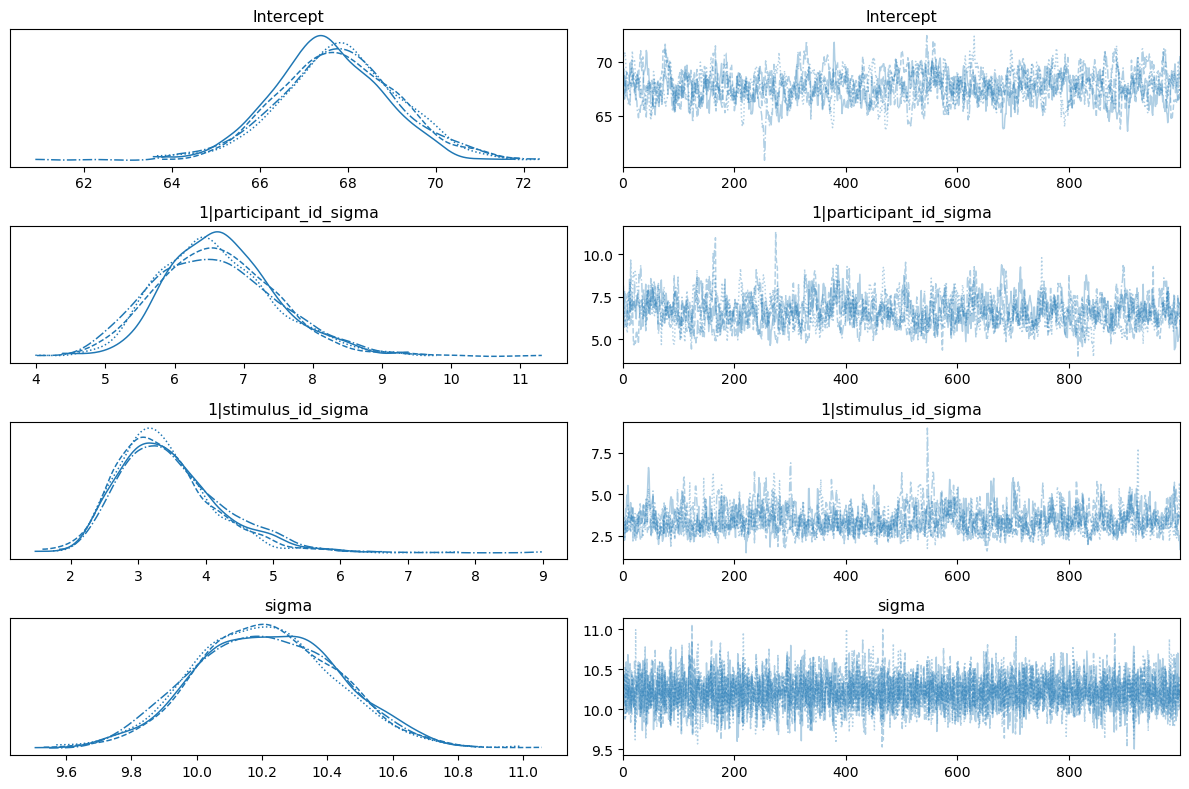

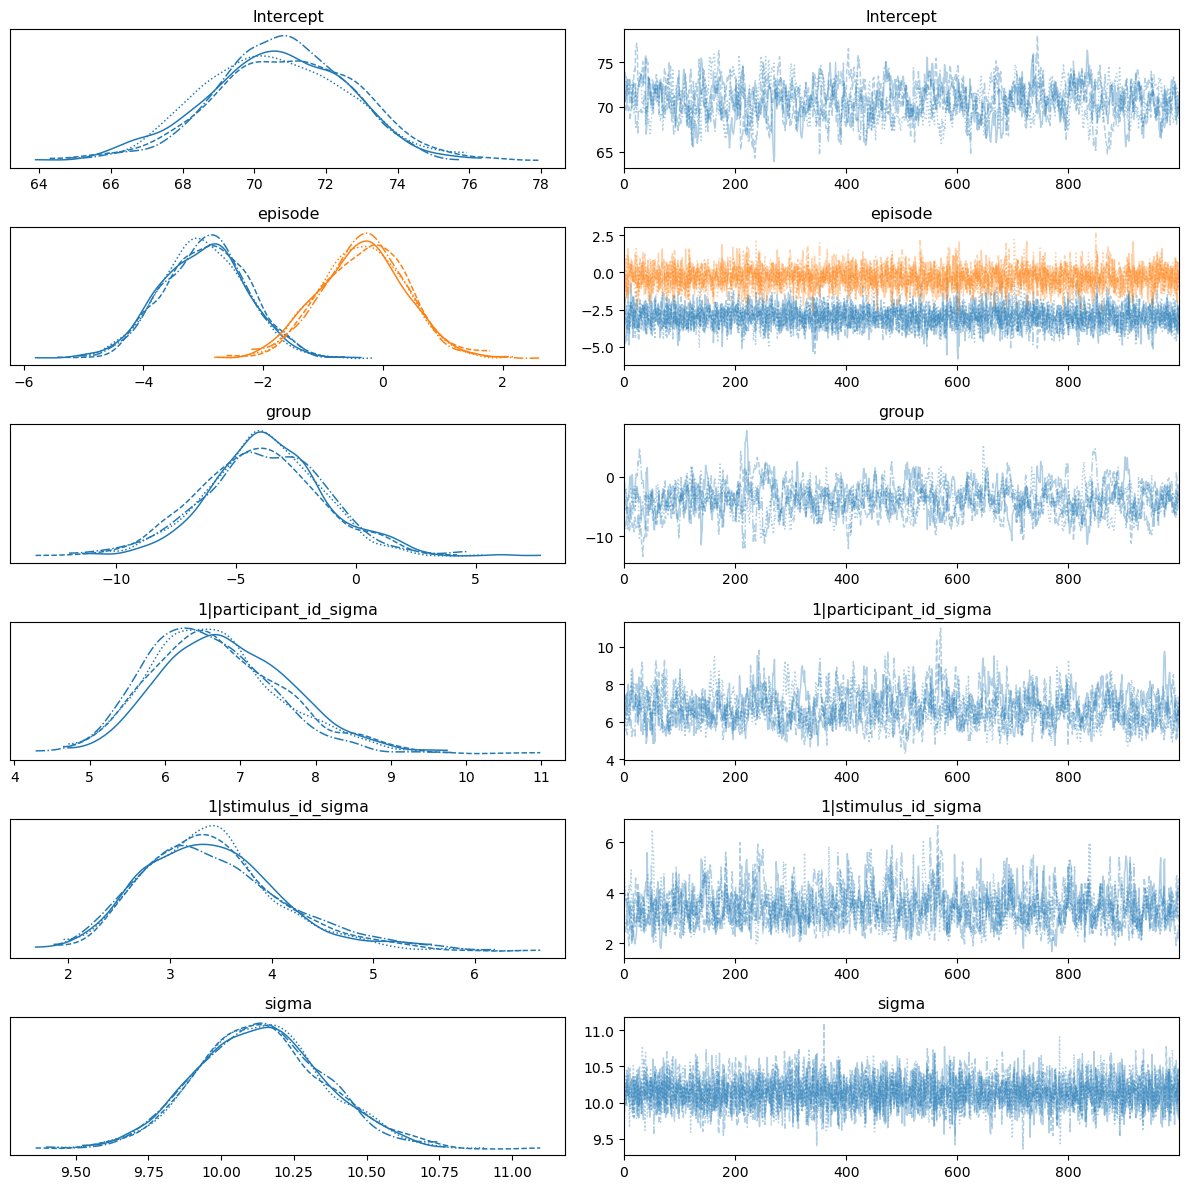

In [12]:
convergence_summary = pd.DataFrame([intercept_diagnostics, full_diagnostics])
display(convergence_summary)

az.plot_trace(intercept_idata, var_names=["Intercept", "1|participant_id_sigma", "1|stimulus_id_sigma", "sigma"], compact=True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intercept_only_selected_trace.png", dpi=150, bbox_inches="tight")
plt.show()

az.plot_trace(full_idata, var_names=["Intercept", "episode", "group", "1|participant_id_sigma", "1|stimulus_id_sigma", "sigma"], compact=True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "additive_stimulus_selected_trace.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Final-Model ICC and Variance-Component Recovery

In [13]:
full_icc_draws = compute_icc_draws(full_idata)
full_icc_summary = summarise_derived_draws(full_icc_draws, ["participant_ICC", "stimulus_ICC", "residual_share"])
full_icc_recovery = full_icc_summary.assign(
    true_value=lambda df: df["parameter"].map(true_icc_values),
    absolute_error=lambda df: (df["mean"] - df["true_value"]).abs(),
    true_inside_hdi=lambda df: (df["true_value"] >= df["hdi_3%"]) & (df["true_value"] <= df["hdi_97%"]),
    model="additive_stimulus",
)
true_component_values = {
    "participant_sd": float(generating_parameters["participant_sd"]),
    "stimulus_sd": float(generating_parameters["stimulus_sd"]),
    "residual_sd": float(generating_parameters["residual_sd"]),
    "participant_variance": float(generating_parameters["participant_variance"]),
    "stimulus_variance": float(generating_parameters["stimulus_variance"]),
    "residual_variance": float(generating_parameters["residual_variance"]),
}
variance_component_summary = summarise_derived_draws(full_icc_draws, list(true_component_values.keys())).assign(
    true_value=lambda df: df["parameter"].map(true_component_values),
    absolute_error=lambda df: (df["mean"] - df["true_value"]).abs(),
    true_inside_hdi=lambda df: (df["true_value"] >= df["hdi_3%"]) & (df["true_value"] <= df["hdi_97%"]),
)
display(full_icc_recovery)
display(variance_component_summary)

,parameter,mean,median,sd,hdi_3%,hdi_97%,true_value,absolute_error,true_inside_hdi,model
0,participant_ICC,0.280380,0.276090,0.052383,0.186652,0.381236,0.338624,0.058244,True,additive_stimulus
1,stimulus_ICC,0.075319,0.070249,0.029098,0.029816,0.132155,0.132275,0.056956,False,additive_stimulus
2,residual_share,0.644301,0.648761,0.052125,0.544712,0.737030,0.529101,0.115200,False,additive_stimulus


,parameter,mean,median,sd,hdi_3%,hdi_97%,true_value,absolute_error,true_inside_hdi
0,participant_sd,6.692227,6.614856,0.867348,5.186803,8.420883,8.0,1.307773,True
1,stimulus_sd,3.419129,3.351359,0.699648,2.160380,4.760528,5.0,1.580871,False
2,residual_sd,10.135003,10.131882,0.215907,9.745908,10.555999,10.0,0.135003,True
3,participant_variance,45.538008,43.756319,12.039200,23.418320,66.784459,64.0,18.461992,True
4,stimulus_variance,12.179825,11.231604,5.179365,4.194199,21.849904,25.0,12.820175,False
5,residual_variance,102.764890,102.655041,4.382278,94.982715,111.429122,100.0,2.764890,True


## 13. Posterior Predictive Checks

In [14]:
def build_mu_for_rows(idata, rows, include_participant):
    intercept = draw_values(idata, "Intercept")
    n_samples = intercept.shape[0]
    mu = np.repeat(intercept[:, None], len(rows), axis=1)
    for j, row in enumerate(rows.itertuples(index=False)):
        mu[:, j] += coefficient_draws(idata, "episode", getattr(row, "episode"), n_samples)
        mu[:, j] += coefficient_draws(idata, "group", getattr(row, "group"), n_samples)
        mu[:, j] += coefficient_draws(idata, "1|stimulus_id", getattr(row, "stimulus_id"), n_samples)
        if include_participant:
            mu[:, j] += coefficient_draws(idata, "1|participant_id", getattr(row, "participant_id"), n_samples)
    return mu

posterior_mu_observed = build_mu_for_rows(full_idata, model_df[["participant_id", "group", "stimulus_id", "episode"]], include_participant=True)
sigma_draws = draw_values(full_idata, "sigma")
posterior_predictive = rng.normal(loc=posterior_mu_observed, scale=sigma_draws[:, None])

ppc_summary = pd.DataFrame([
    {"metric": "observed_mean", "value": model_df["rating"].mean()},
    {"metric": "posterior_predictive_mean", "value": posterior_predictive.mean()},
    {"metric": "observed_sd", "value": model_df["rating"].std(ddof=1)},
    {"metric": "posterior_predictive_sd", "value": posterior_predictive.std(ddof=1)},
    {"metric": "ppc_below_0", "value": float((posterior_predictive < 0).mean())},
    {"metric": "ppc_above_100", "value": float((posterior_predictive > 100).mean())},
    {"metric": "ppc_outside_0_100", "value": float(((posterior_predictive < 0) | (posterior_predictive > 100)).mean())},
])
ppc_group_rows = []
for factor in ["episode", "group", "stimulus_id"]:
    for level in model_df[factor].astype(str).unique():
        mask = model_df[factor].astype(str).to_numpy() == level
        pred_means = posterior_predictive[:, mask].mean(axis=1)
        lower, upper = hdi_bounds(pred_means)
        ppc_group_rows.append({"factor": factor, "level": level, "observed_mean": model_df.loc[mask, "rating"].mean(), "posterior_predictive_mean": pred_means.mean(), "hdi_3%": lower, "hdi_97%": upper, "absolute_error": abs(pred_means.mean() - model_df.loc[mask, "rating"].mean())})
ppc_group_summary = pd.DataFrame(ppc_group_rows)
display(ppc_summary)
display(ppc_group_summary.head(30))

,metric,value
0,observed_mean,67.635500
1,posterior_predictive_mean,67.642831
2,observed_sd,12.483645
3,posterior_predictive_sd,12.532039
4,ppc_below_0,0.000000
5,ppc_above_100,0.005342
6,ppc_outside_0_100,0.005342


,factor,level,observed_mean,posterior_predictive_mean,hdi_3%,hdi_97%,absolute_error
0,episode,EDR-1,68.740531,68.745114,67.330535,70.033719,0.004583
1,episode,EDR-2,65.759160,65.765227,64.415133,67.107428,0.006068
2,episode,FM-1,68.406810,68.418153,67.076006,69.783219,0.011343
3,group,group_01,69.514215,69.523636,68.390005,70.563753,0.009421
4,group,group_02,65.756786,65.762027,64.651372,66.841535,0.005241
5,stimulus_id,lead_me_du_d,69.884484,69.880451,66.605387,73.153818,0.004034
6,stimulus_id,lead_me_du_e,70.455171,70.335172,67.070003,73.671506,0.120000
7,stimulus_id,lead_me_pxl_l1,66.175695,66.670021,63.228311,70.006748,0.494326
8,stimulus_id,lead_me_pxl_l4,71.404695,71.179541,67.740335,74.500738,0.225154
9,stimulus_id,lead_me_mcg_pro2,67.657362,67.921410,64.520389,71.113039,0.264048


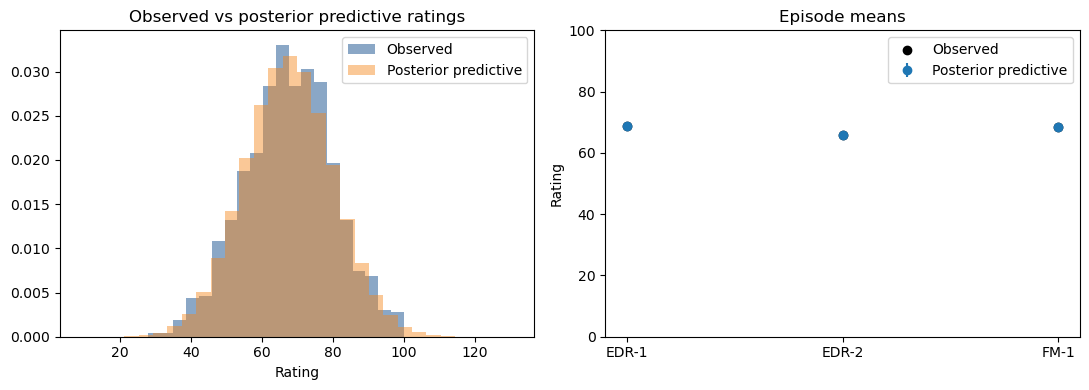

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(model_df["rating"], bins=20, alpha=0.65, label="Observed", color="#4C78A8", density=True)
axes[0].hist(posterior_predictive.reshape(-1), bins=30, alpha=0.45, label="Posterior predictive", color="#F58518", density=True)
axes[0].set_title("Observed vs posterior predictive ratings")
axes[0].set_xlabel("Rating")
axes[0].legend()
comparison = ppc_group_summary.loc[ppc_group_summary["factor"] == "episode"]
axes[1].errorbar(comparison["level"], comparison["posterior_predictive_mean"], yerr=[comparison["posterior_predictive_mean"] - comparison["hdi_3%"], comparison["hdi_97%"] - comparison["posterior_predictive_mean"]], fmt="o", label="Posterior predictive")
axes[1].scatter(comparison["level"], comparison["observed_mean"], color="black", label="Observed")
axes[1].set_title("Episode means")
axes[1].set_ylabel("Rating")
axes[1].set_ylim(0, 100)
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "posterior_predictive_checks.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Fixed-Effect Recovery

In [16]:
n_samples = draw_values(full_idata, "Intercept").shape[0]
true_group_effects = generating_parameters["group_effects"]
true_episode_effects = generating_parameters["episode_effects"]
grand_mean = float(generating_parameters["grand_mean"])
coef_truth = {"Intercept": grand_mean + true_group_effects[GROUP_LEVELS[0]] + true_episode_effects[EPISODE_LEVELS[0]]}
for episode in EPISODE_LEVELS[1:]:
    coef_truth[f"episode[{episode}]"] = true_episode_effects[episode] - true_episode_effects[EPISODE_LEVELS[0]]
for group in GROUP_LEVELS[1:]:
    coef_truth[f"group[{group}]"] = true_group_effects[group] - true_group_effects[GROUP_LEVELS[0]]
fixed_effect_recovery = fixed_effect_summary.assign(
    true_value=lambda df: df["parameter"].map(coef_truth),
    absolute_error=lambda df: (df["mean"] - df["true_value"]).abs(),
    true_inside_hdi=lambda df: (df["true_value"] >= df["hdi_3%"]) & (df["true_value"] <= df["hdi_97%"]),
)
population_mean_rows = []
for group in GROUP_LEVELS:
    for episode in EPISODE_LEVELS:
        draws = draw_values(full_idata, "Intercept") + coefficient_draws(full_idata, "group", group, n_samples) + coefficient_draws(full_idata, "episode", episode, n_samples)
        lower, upper = hdi_bounds(draws)
        true_mean = grand_mean + true_group_effects[group] + true_episode_effects[episode]
        population_mean_rows.append({"group": group, "episode": episode, "true_expected_mean": true_mean, "posterior_mean": float(draws.mean()), "hdi_3%": lower, "hdi_97%": upper, "absolute_error": abs(float(draws.mean()) - true_mean), "true_inside_hdi": lower <= true_mean <= upper})
episode_group_recovery = pd.DataFrame(population_mean_rows)
episode_group_rmse = float(np.sqrt(np.mean((episode_group_recovery["posterior_mean"] - episode_group_recovery["true_expected_mean"]) ** 2)))
episode_group_coverage = float(episode_group_recovery["true_inside_hdi"].mean())
display(fixed_effect_recovery)
display(episode_group_recovery)
print(f"Episode x group population-mean RMSE: {episode_group_rmse:.3f}")
print(f"Episode x group population-mean HDI coverage: {episode_group_coverage:.3f}")

,parameter,mean,median,sd,hdi_3%,hdi_97%,mcse_mean,ess_bulk,ess_tail,r_hat,true_value,absolute_error,true_inside_hdi
0,Intercept,70.710,70.728864,1.959,67.203,74.497,0.107,334.0,839.0,1.01,68.0,2.710,True
1,episode[EDR-2],-2.982,-2.972858,0.715,-4.233,-1.565,0.013,3120.0,2771.0,1.00,-3.5,0.518,True
2,episode[FM-1],-0.325,-0.305299,0.725,-1.724,0.957,0.013,3194.0,3191.0,1.00,-1.0,0.675,True
3,group[group_02],-3.828,-3.877925,2.519,-8.832,0.790,0.152,275.0,523.0,1.01,1.5,5.328,False


,group,episode,true_expected_mean,posterior_mean,hdi_3%,hdi_97%,absolute_error,true_inside_hdi
0,group_01,EDR-1,68.0,70.709591,67.203110,74.496936,2.709591,True
1,group_01,EDR-2,64.5,67.727580,64.180105,71.402104,3.227580,True
2,group_01,FM-1,67.0,70.384825,66.564528,73.863247,3.384825,True
3,group_02,EDR-1,69.5,66.881574,63.252112,70.607173,2.618426,True
4,group_02,EDR-2,66.0,63.899563,60.372781,67.514527,2.100437,True
5,group_02,FM-1,68.5,66.556807,62.741315,70.018100,1.943193,True


Episode x group population-mean RMSE: 2.716
Episode x group population-mean HDI coverage: 1.000


## 15. Posterior Expected Ratings for Valid Episode-Group-Stimulus Combinations

In [17]:
prediction_grid = stimulus_metadata[["group", "song_id", "song_title", "mix_id", "stimulus_id", "original_mix_name"]].merge(pd.DataFrame({"episode": EPISODE_LEVELS}), how="cross").sort_values(["song_id", "episode", "stimulus_id"]).reset_index(drop=True)
posterior_mu_grid = build_mu_for_rows(full_idata, prediction_grid[["group", "stimulus_id", "episode"]], include_participant=False)
expected_rows = []
for idx, row in prediction_grid.iterrows():
    draws = posterior_mu_grid[:, idx]
    lower, upper = hdi_bounds(draws)
    expected_rows.append({"song_id": row["song_id"], "song_title": row["song_title"], "group": row["group"], "episode": row["episode"], "stimulus_id": row["stimulus_id"], "mix_id": row["mix_id"], "original_mix_name": row["original_mix_name"], "posterior_mean_expected_rating": float(draws.mean()), "hdi_3%": lower, "hdi_97%": upper})
posterior_expected_ratings = pd.DataFrame(expected_rows)
posterior_expected_ratings.head(15)

,song_id,song_title,group,episode,stimulus_id,mix_id,original_mix_name,posterior_mean_expected_rating,hdi_3%,hdi_97%
0,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s1,mix_9ffcd672af17,PXL-S1,70.772380,67.190131,74.583938
1,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s2,mix_6f8b655d7999,PXL-S2,72.876521,69.377737,76.744445
2,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s3,mix_65f41f41d3ab,PXL-S3,69.402745,65.738299,73.127455
3,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s5,mix_82d60d7c7fc5,PXL-S5,70.646633,67.191511,74.607674
4,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s7,mix_b393d3919c78,PXL-S7,71.369262,67.797984,75.033970
5,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s1,mix_9ffcd672af17,PXL-S1,67.790369,64.197762,71.545781
6,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s2,mix_6f8b655d7999,PXL-S2,69.894510,66.114677,73.449453
7,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s3,mix_65f41f41d3ab,PXL-S3,66.420733,62.762208,70.137068
8,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s5,mix_82d60d7c7fc5,PXL-S5,67.664622,63.699736,71.206719
9,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s7,mix_b393d3919c78,PXL-S7,68.387251,65.040411,72.500055


## 16. Posterior Preferred-Mix Probabilities

For each `song_id x episode`, the five candidate stimuli are compared draw-by-draw using posterior expected rating draws. Exact draw-level ties receive fractional winning credit. Final probability ties are flagged and a single deterministic winner is selected by sorting tied candidates by `stimulus_id`.

In [18]:
winner_rows = []
winner_validation_rows = []
for (song_id, episode), group_df in posterior_expected_ratings.groupby(["song_id", "episode"], sort=True):
    group_df = group_df.sort_values("stimulus_id").reset_index(drop=True)
    grid_indices = posterior_expected_ratings.index[(posterior_expected_ratings["song_id"] == song_id) & (posterior_expected_ratings["episode"] == episode)].to_numpy()
    grid_indices = posterior_expected_ratings.loc[grid_indices].sort_values("stimulus_id").index.to_numpy()
    draw_matrix = posterior_mu_grid[:, grid_indices]
    max_per_draw = draw_matrix.max(axis=1, keepdims=True)
    draw_winners = np.isclose(draw_matrix, max_per_draw, rtol=0.0, atol=1e-12)
    fractional_credit = draw_winners / draw_winners.sum(axis=1, keepdims=True)
    probabilities = fractional_credit.mean(axis=0)
    draw_level_tie_count = int((draw_winners.sum(axis=1) > 1).sum())
    max_probability = probabilities.max()
    final_probability_tie_mask = np.isclose(probabilities, max_probability, rtol=0.0, atol=1e-12)
    deterministic_winner_position = int(np.where(final_probability_tie_mask)[0][0])
    for position, (_, row) in enumerate(group_df.iterrows()):
        winner_rows.append({"song_id": row["song_id"], "song_title": row["song_title"], "group": row["group"], "episode": row["episode"], "stimulus_id": row["stimulus_id"], "mix_id": row["mix_id"], "original_mix_name": row["original_mix_name"], "posterior_mean_expected_rating": row["posterior_mean_expected_rating"], "hdi_3%": row["hdi_3%"], "hdi_97%": row["hdi_97%"], "posterior_probability_highest": float(probabilities[position]), "draw_level_tie_count": draw_level_tie_count, "is_final_probability_tie": bool(final_probability_tie_mask[position] and final_probability_tie_mask.sum() > 1), "is_final_predicted_winner": bool(position == deterministic_winner_position), "winner_rule": "largest posterior_probability_highest; exact probability ties resolved by stimulus_id sort order"})
    winner_validation_rows.append({"song_id": song_id, "episode": episode, "n_candidates": len(group_df), "probability_sum": float(probabilities.sum()), "probabilities_between_0_and_1": bool(((probabilities >= 0) & (probabilities <= 1)).all()), "n_final_winners": 1, "draw_level_tie_count": draw_level_tie_count, "final_probability_tie": bool(final_probability_tie_mask.sum() > 1)})
posterior_highest_rated_mixes = pd.DataFrame(winner_rows)
posterior_winner_validation = pd.DataFrame(winner_validation_rows)
winner_checks_passed = (
    (posterior_winner_validation["n_candidates"] == 5).all()
    and posterior_winner_validation["probabilities_between_0_and_1"].all()
    and np.allclose(posterior_winner_validation["probability_sum"], 1.0, atol=1e-10)
    and (posterior_highest_rated_mixes.groupby(["song_id", "episode"])["is_final_predicted_winner"].sum() == 1).all()
)
if not winner_checks_passed:
    raise AssertionError("Posterior winner validation failed.")
display(posterior_highest_rated_mixes)
display(posterior_winner_validation)

,song_id,song_title,group,episode,stimulus_id,mix_id,original_mix_name,posterior_mean_expected_rating,hdi_3%,hdi_97%,posterior_probability_highest,draw_level_tie_count,is_final_probability_tie,is_final_predicted_winner,winner_rule
0,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s1,mix_9ffcd672af17,PXL-S1,70.772380,67.190131,74.583938,0.06400,0,False,False,largest posterior_probability_highest; exact p...
1,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s2,mix_6f8b655d7999,PXL-S2,72.876521,69.377737,76.744445,0.71600,0,False,True,largest posterior_probability_highest; exact p...
2,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s3,mix_65f41f41d3ab,PXL-S3,69.402745,65.738299,73.127455,0.00850,0,False,False,largest posterior_probability_highest; exact p...
3,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s5,mix_82d60d7c7fc5,PXL-S5,70.646633,67.191511,74.607674,0.05725,0,False,False,largest posterior_probability_highest; exact p...
4,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s7,mix_b393d3919c78,PXL-S7,71.369262,67.797984,75.033970,0.15425,0,False,False,largest posterior_probability_highest; exact p...
5,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s1,mix_9ffcd672af17,PXL-S1,67.790369,64.197762,71.545781,0.06400,0,False,False,largest posterior_probability_highest; exact p...
6,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s2,mix_6f8b655d7999,PXL-S2,69.894510,66.114677,73.449453,0.71600,0,False,True,largest posterior_probability_highest; exact p...
7,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s3,mix_65f41f41d3ab,PXL-S3,66.420733,62.762208,70.137068,0.00850,0,False,False,largest posterior_probability_highest; exact p...
8,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s5,mix_82d60d7c7fc5,PXL-S5,67.664622,63.699736,71.206719,0.05725,0,False,False,largest posterior_probability_highest; exact p...
9,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s7,mix_b393d3919c78,PXL-S7,68.387251,65.040411,72.500055,0.15425,0,False,False,largest posterior_probability_highest; exact p...


,song_id,episode,n_candidates,probability_sum,probabilities_between_0_and_1,n_final_winners,draw_level_tie_count,final_probability_tie
0,id_like_to_know,EDR-1,5,1.0,True,1,0,False
1,id_like_to_know,EDR-2,5,1.0,True,1,0,False
2,id_like_to_know,FM-1,5,1.0,True,1,0,False
3,in_the_meantime,EDR-1,5,1.0,True,1,0,False
4,in_the_meantime,EDR-2,5,1.0,True,1,0,False
5,in_the_meantime,FM-1,5,1.0,True,1,0,False
6,lead_me,EDR-1,5,1.0,True,1,0,False
7,lead_me,EDR-2,5,1.0,True,1,0,False
8,lead_me,FM-1,5,1.0,True,1,0,False
9,pouring_room,EDR-1,5,1.0,True,1,0,False


## 17. Interpretation Boundaries

The stimulus-based model is additive and does not contain Episode x Stimulus interactions. Therefore differences among stimuli are assumed to be constant across episodes on the model scale.

The model can estimate overall episode differences, overall group difference, participant variability, and stimulus variability. It cannot support claims that a specific stimulus changes its relative preference differently across episodes.

`group` is a fixed design factor but is confounded with the song allocation. The group coefficient represents systematic differences between the two assigned song sets / study groups and must not be interpreted as a pure participant-group causal effect.

## 18. Export Model Outputs

In [19]:
all_icc_recovery = pd.concat([intercept_icc_recovery, full_icc_recovery], ignore_index=True)
runtime_summary = pd.DataFrame([
    {"model": "intercept_only", "formula": INTERCEPT_ONLY_FORMULA, "runtime_seconds": intercept_runtime_seconds, **SAMPLING_CONFIG},
    {"model": "additive_stimulus", "formula": FULL_MODEL_FORMULA, "runtime_seconds": full_runtime_seconds, **SAMPLING_CONFIG},
])
execution_summary = pd.DataFrame([
    {"item": "notebook", "value": "statistical-baseline/notebooks/_02_categorical_stimulus_model.ipynb"},
    {"item": "intercept_only_formula", "value": INTERCEPT_ONLY_FORMULA},
    {"item": "full_model_formula", "value": FULL_MODEL_FORMULA},
    {"item": "sampling_config", "value": json.dumps(SAMPLING_CONFIG)},
    {"item": "intercept_runtime_seconds", "value": intercept_runtime_seconds},
    {"item": "full_runtime_seconds", "value": full_runtime_seconds},
    {"item": "true_participant_ICC", "value": true_icc_values["participant_ICC"]},
    {"item": "posterior_participant_ICC_mean", "value": float(full_icc_recovery.loc[full_icc_recovery["parameter"] == "participant_ICC", "mean"].iloc[0])},
    {"item": "true_stimulus_ICC", "value": true_icc_values["stimulus_ICC"]},
    {"item": "posterior_stimulus_ICC_mean", "value": float(full_icc_recovery.loc[full_icc_recovery["parameter"] == "stimulus_ICC", "mean"].iloc[0])},
    {"item": "ppc_outside_0_100", "value": float(ppc_summary.loc[ppc_summary["metric"] == "ppc_outside_0_100", "value"].iloc[0])},
    {"item": "episode_group_rmse", "value": episode_group_rmse},
    {"item": "episode_group_coverage", "value": episode_group_coverage},
    {"item": "posterior_winner_validation_passed", "value": winner_checks_passed},
])
export_paths = {
    "fixed_effect_posterior_summary": OUTPUT_DIR / "fixed_effect_posterior_summary.csv",
    "fixed_effect_recovery": OUTPUT_DIR / "fixed_effect_recovery.csv",
    "variance_component_summary": OUTPUT_DIR / "variance_component_summary.csv",
    "icc_posterior_summary": OUTPUT_DIR / "icc_posterior_summary.csv",
    "icc_recovery_summary": OUTPUT_DIR / "icc_recovery_summary.csv",
    "convergence_diagnostics": OUTPUT_DIR / "convergence_diagnostics.csv",
    "posterior_predictive_summary": OUTPUT_DIR / "posterior_predictive_summary.csv",
    "posterior_predictive_group_summary": OUTPUT_DIR / "posterior_predictive_group_summary.csv",
    "episode_group_recovery": OUTPUT_DIR / "episode_group_recovery_table.csv",
    "posterior_expected_ratings": OUTPUT_DIR / "posterior_expected_ratings.csv",
    "posterior_highest_rated_mixes": OUTPUT_DIR / "predicted_highest_rated_mixes.csv",
    "posterior_winner_validation": OUTPUT_DIR / "posterior_winner_validation.csv",
    "runtime_summary": OUTPUT_DIR / "runtime_execution_summary.csv",
    "execution_summary": OUTPUT_DIR / "execution_summary.csv",
    "intercept_idata": OUTPUT_DIR / "intercept_only_stimulus_model_idata.nc",
    "full_idata": OUTPUT_DIR / "additive_stimulus_model_idata.nc",
}
fixed_effect_summary.to_csv(export_paths["fixed_effect_posterior_summary"], index=False)
fixed_effect_recovery.to_csv(export_paths["fixed_effect_recovery"], index=False)
variance_component_summary.to_csv(export_paths["variance_component_summary"], index=False)
full_icc_summary.to_csv(export_paths["icc_posterior_summary"], index=False)
all_icc_recovery.to_csv(export_paths["icc_recovery_summary"], index=False)
convergence_summary.to_csv(export_paths["convergence_diagnostics"], index=False)
ppc_summary.to_csv(export_paths["posterior_predictive_summary"], index=False)
ppc_group_summary.to_csv(export_paths["posterior_predictive_group_summary"], index=False)
episode_group_recovery.to_csv(export_paths["episode_group_recovery"], index=False)
posterior_expected_ratings.to_csv(export_paths["posterior_expected_ratings"], index=False)
posterior_highest_rated_mixes.to_csv(export_paths["posterior_highest_rated_mixes"], index=False)
posterior_winner_validation.to_csv(export_paths["posterior_winner_validation"], index=False)
runtime_summary.to_csv(export_paths["runtime_summary"], index=False)
execution_summary.to_csv(export_paths["execution_summary"], index=False)
export_summary = pd.DataFrame([{"artifact": key, "path": str(path.relative_to(REPO_ROOT)), "exists": path.exists()} for key, path in export_paths.items()])
export_summary

,artifact,path,exists
0,fixed_effect_posterior_summary,statistical-baseline\outputs\stimulus_model\fi...,True
1,fixed_effect_recovery,statistical-baseline\outputs\stimulus_model\fi...,True
2,variance_component_summary,statistical-baseline\outputs\stimulus_model\va...,True
3,icc_posterior_summary,statistical-baseline\outputs\stimulus_model\ic...,True
4,icc_recovery_summary,statistical-baseline\outputs\stimulus_model\ic...,True
5,convergence_diagnostics,statistical-baseline\outputs\stimulus_model\co...,True
6,posterior_predictive_summary,statistical-baseline\outputs\stimulus_model\po...,True
7,posterior_predictive_group_summary,statistical-baseline\outputs\stimulus_model\po...,True
8,episode_group_recovery,statistical-baseline\outputs\stimulus_model\ep...,True
9,posterior_expected_ratings,statistical-baseline\outputs\stimulus_model\po...,True


## 19. Limitations and Next Steps

The synthetic data are not empirical results. The group coefficient is confounded with song allocation and should not be interpreted as a pure participant-group causal effect. The additive model does not model context-specific stimulus changes, so it cannot support claims that individual stimuli change relative preference differently across episodes.

The Gaussian boundary behaviour is acceptable for this synthetic scenario only and must be reassessed on real participant data. The next notebook will update the final 20-stimulus acoustic-feature exploration. The feature-based model will then test whether objective acoustic predictors explain between-stimulus rating variation.

In [20]:
completion_report = {
    "notebook": "statistical-baseline/notebooks/_02_categorical_stimulus_model.ipynb",
    "formulas_fitted": [INTERCEPT_ONLY_FORMULA, FULL_MODEL_FORMULA],
    "sampling_config": SAMPLING_CONFIG,
    "intercept_runtime_seconds": intercept_runtime_seconds,
    "full_runtime_seconds": full_runtime_seconds,
    "intercept_diagnostics": intercept_diagnostics,
    "full_diagnostics": full_diagnostics,
    "true_participant_ICC": true_icc_values["participant_ICC"],
    "posterior_participant_ICC_mean": float(full_icc_recovery.loc[full_icc_recovery["parameter"] == "participant_ICC", "mean"].iloc[0]),
    "participant_ICC_absolute_error": float(full_icc_recovery.loc[full_icc_recovery["parameter"] == "participant_ICC", "absolute_error"].iloc[0]),
    "true_stimulus_ICC": true_icc_values["stimulus_ICC"],
    "posterior_stimulus_ICC_mean": float(full_icc_recovery.loc[full_icc_recovery["parameter"] == "stimulus_ICC", "mean"].iloc[0]),
    "stimulus_ICC_absolute_error": float(full_icc_recovery.loc[full_icc_recovery["parameter"] == "stimulus_ICC", "absolute_error"].iloc[0]),
    "ppc_boundary_violation_rate": float(ppc_summary.loc[ppc_summary["metric"] == "ppc_outside_0_100", "value"].iloc[0]),
    "episode_group_rmse": episode_group_rmse,
    "episode_group_coverage": episode_group_coverage,
    "posterior_winner_validation_passed": winner_checks_passed,
    "exported_files": export_summary.loc[export_summary["exists"], "path"].tolist(),
}
completion_report

{'notebook': 'statistical-baseline/notebooks/_02_categorical_stimulus_model.ipynb',
 'formulas_fitted': ['rating ~ 1 + (1 | participant_id) + (1 | stimulus_id)',
  'rating ~ episode + group + (1 | participant_id) + (1 | stimulus_id)'],
 'sampling_config': {'draws': 1000,
  'tune': 1000,
  'chains': 4,
  'cores': 1,
  'target_accept': 0.95,
  'random_seed': 42,
  'inference_method': 'nutpie'},
 'intercept_runtime_seconds': 11.01500939996913,
 'full_runtime_seconds': 36.518881199881434,
 'intercept_diagnostics': {'model': 'intercept_only',
  'divergences': 0,
  'max_rhat': 1.01,
  'min_bulk_ess': 361.0,
  'min_tail_ess': 725.0,
  'max_treedepth_warnings': 0,
  'min_bfmi': 0.5806642004956757},
 'full_diagnostics': {'model': 'additive_stimulus',
  'divergences': 0,
  'max_rhat': 1.02,
  'min_bulk_ess': 275.0,
  'min_tail_ess': 523.0,
  'max_treedepth_warnings': 0,
  'min_bfmi': 0.6457919241436011},
 'true_participant_ICC': 0.3386243386243386,
 'posterior_participant_ICC_mean': 0.2803799662